# Advanced XGBoost Model for Wind Turbine Anomaly Detection

## Problem Formulation

We operate two wind turbines equipped with **238 sensors** that record average measurements every **10 minutes**. An observer has manually labeled each window as `"Normal"` or `"Anomalous"`, while many timestamps were left as `"Unknown"` during a break.

**Goal:** Train an advanced model that outperforms the Logistic Regression baseline while maintaining directly comparable evaluation methods, then predict the status of all `"Unknown"` timestamps.

### Why XGBoost?

We move beyond the linear baseline to **XGBoost** because:
1. **Non-linear relationships** — Sensor interactions in turbines are inherently non-linear. XGBoost captures complex feature interactions through its ensemble of decision trees.
2. **Superior performance** — Gradient-boosted trees consistently outperform linear models on structured/tabular data.
3. **Built-in regularisation** — Parameters like `max_depth`, `subsample`, `colsample_bytree` prevent overfitting without needing external feature scaling.
4. **Interpretability via SHAP** — Unlike linear coefficients, SHAP values explain the *actual* non-linear contribution of each feature, giving richer insight into turbine behaviour.

### Enhancements over the Baseline

| Aspect | Baseline (Logistic Regression) | XGBoost Model |
|---|---|---|
| Feature engineering | `hour`, `month`, `day_of_week` | + Lag features + Rolling statistics |
| Class imbalance | `class_weight='balanced'` | `scale_pos_weight` (neg/pos ratio) |
| Hyperparameter tuning | None (default params) | **Optuna** with `TimeSeriesSplit` |
| Interpretability | Linear coefficients | **SHAP** values |
| Feature scaling | StandardScaler required | Not required (tree-based) |

### Key Data Insights

| Property | Dataset A | Dataset B |
|---|---|---|
| Rows | 54,865 | 63,003 |
| Columns | 241 | 241 |
| Normal | 44,217 (80.6%) | 48,952 (77.7%) |
| Anomalous | 8,343 (15.2%) | 3,608 (5.7%) |
| Unknown | 2,305 (4.2%) | 10,443 (16.6%) |
| Missing values | **0** | **0** |
| Time interval | 10 min, continuous | 10 min, continuous |

**Key observations:**
- **No missing values** — we skip imputation.
- **Severe class imbalance** — especially in Dataset B (5.7 % Anomalous). `scale_pos_weight` will address this.
- **Temporal structure** — chronological splitting avoids data leakage.

---
## Step 1: Load Data and Import Libraries

We load both CSV files (`;` separated), parse timestamps, and import all libraries we will need throughout the notebook — including `xgboost`, `optuna`, and `shap` for the advanced modelling pipeline.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix,
    precision_recall_curve, auc, ConfusionMatrixDisplay
)

import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # keep output clean
import shap

# Load both datasets
df_a = pd.read_csv('wind_turbine_snippet_A.csv', sep=';', parse_dates=['time_stamp'])
df_b = pd.read_csv('wind_turbine_snippet_B.csv', sep=';', parse_dates=['time_stamp'])

print(f'Dataset A: {df_a.shape[0]} rows, {df_a.shape[1]} columns')
print(f'Dataset B: {df_b.shape[0]} rows, {df_b.shape[1]} columns')

Dataset A: 54865 rows, 241 columns
Dataset B: 63003 rows, 241 columns


---
## Step 2: Feature Engineering (Baseline Parity + Advanced Features)

### Temporal features (same as baseline)
We extract `hour`, `month`, and `day_of_week` from the timestamp. This gives the model access to cyclic patterns like hour-of-day effects in wind behaviour and anomaly clustering.

### Advanced features (new)
In addition to the baseline temporal features, we engineer:

1. **Lag features** — Previous values (1-step and 3-step lags) of key sensors (`Wind speed 1+2 (avg)`, `Active power grid side converter (avg)`) capture recent trends. If the wind speed was abnormally high or low shortly before a reading, that is valuable context.

2. **Rolling window statistics** — 3-hour (18-step) moving average and moving standard deviation of the same key sensors. These smooth out noise and capture the short-term *volatility* of the turbine's behaviour — sudden changes in rolling std often precede anomalies.

### Why combine both datasets?
Both turbines share the same 241 columns (sensor setup). Training on both gives more labelled data. The `asset_id` tells the model which turbine is which, allowing turbine-specific patterns.

In [7]:
# Key sensor columns for lag/rolling features
KEY_SENSORS = ['Wind speed 1+2 (avg)', 'Active power grid side converter (avg)']

def engineer_features(df):
    """Extract temporal features and generate lag/rolling features."""
    df = df.copy()

    # --- Temporal features (baseline parity) ---
    df['hour'] = df['time_stamp'].dt.hour
    df['month'] = df['time_stamp'].dt.month
    df['day_of_week'] = df['time_stamp'].dt.dayofweek

    # --- Advanced features ---
    # Sort by time to ensure correct lag/rolling computation
    df = df.sort_values('time_stamp').reset_index(drop=True)

    for col in KEY_SENSORS:
        safe = col.replace(' ', '_').replace('(', '').replace(')', '').replace('+', 'p')
        # Lag features (1-step = 10 min, 3-step = 30 min)
        df[f'{safe}_lag1'] = df[col].shift(1)
        df[f'{safe}_lag3'] = df[col].shift(3)
        # Rolling 3-hour window (18 steps × 10 min = 180 min)
        df[f'{safe}_roll_mean_18'] = df[col].rolling(window=18, min_periods=1).mean()
        df[f'{safe}_roll_std_18']  = df[col].rolling(window=18, min_periods=1).std().fillna(0)

    # Fill NaN created by shift with 0
    df = df.fillna(0)
    return df

df_a = engineer_features(df_a)
df_b = engineer_features(df_b)

# Combine both datasets for joint training
df_combined = pd.concat([df_a, df_b], ignore_index=True)
print(f'Combined dataset: {df_combined.shape[0]} rows, {df_combined.shape[1]} columns')
print(f'\nNew feature columns added:')
for c in df_combined.columns:
    if 'lag' in c or 'roll' in c:
        print(f'  • {c}')
print(f'\nStatus distribution in combined data:')
print(df_combined['status'].value_counts())

Combined dataset: 117868 rows, 252 columns

New feature columns added:
  • Wind_speed_1p2_avg_lag1
  • Wind_speed_1p2_avg_lag3
  • Wind_speed_1p2_avg_roll_mean_18
  • Wind_speed_1p2_avg_roll_std_18
  • Active_power_grid_side_converter_avg_lag1
  • Active_power_grid_side_converter_avg_lag3
  • Active_power_grid_side_converter_avg_roll_mean_18
  • Active_power_grid_side_converter_avg_roll_std_18

Status distribution in combined data:
status
Normal       93169
Unknown      12748
Anomalous    11951
Name: count, dtype: int64


---
## Step 3: Prepare Labeled and Unlabeled Sets

We split the combined data into:
1. **Labeled set** — rows where `status` is `"Normal"` or `"Anomalous"`. This is our training/validation data.
2. **Unlabeled set** — rows where `status` is `"Unknown"`. We predict these after training.

We encode: `Normal → 0`, `Anomalous → 1`. We drop `time_stamp` (already extracted temporal features) and `status` (target, not a feature).

> **Note:** Unlike the baseline, we do **not** need `StandardScaler` because XGBoost is a tree-based model and is invariant to feature scaling.

In [8]:
# Separate labeled (Normal/Anomalous) from unlabeled (Unknown)
df_labeled = df_combined[df_combined['status'] != 'Unknown'].copy()
df_unknown = df_combined[df_combined['status'] == 'Unknown'].copy()

print(f'Labeled samples: {len(df_labeled)} (Normal: {(df_labeled["status"]=="Normal").sum()}, Anomalous: {(df_labeled["status"]=="Anomalous").sum()})')
print(f'Unknown samples to predict: {len(df_unknown)}')

# Encode labels: Normal=0, Anomalous=1
label_map = {'Normal': 0, 'Anomalous': 1}
y_labeled = df_labeled['status'].map(label_map)

# Define feature columns
drop_cols = ['time_stamp', 'status']
feature_cols = [c for c in df_labeled.columns if c not in drop_cols]

X_labeled = df_labeled[feature_cols]
X_unknown = df_unknown[feature_cols]

print(f'\nNumber of features: {len(feature_cols)}')
print(f'Feature columns include: asset_id, hour, month, day_of_week, + 238 sensor columns + lag/rolling features')

Labeled samples: 105120 (Normal: 93169, Anomalous: 11951)
Unknown samples to predict: 12748

Number of features: 250
Feature columns include: asset_id, hour, month, day_of_week, + 238 sensor columns + lag/rolling features


---
## Step 4: Chronological Train/Validation Split (Baseline Parity)

### Why NOT a random split?

This is **time-series data**. Random splitting would allow the model to "see the future", causing data leakage and overly optimistic scores.

### What we do instead

Exactly mirroring the baseline: sort by `time_stamp` and take the **last 20 %** (chronologically) as the validation set. This simulates a realistic scenario — the model learns from past data and is tested on future data.

In [9]:
# --- Step 4: Pooled Global Chronological Train/Validation Split ---

# STRATEGY: We pool the data BEFORE splitting to enforce a single global cutoff date. 
# Splitting turbines independently would result in different cutoff dates, allowing 
# Turbine A's training data to overlap chronologically with Turbine B's validation data, 
# causing cross-asset temporal data leakage.

# Sort the globally pooled labeled data chronologically
df_labeled_sorted = df_labeled.sort_values('time_stamp').reset_index(drop=True)

# Separate target and features after the global sort
y_sorted = df_labeled_sorted['status'].map(label_map)
X_sorted = df_labeled_sorted[feature_cols]

# Chronological 80/20 global split
split_idx = int(len(X_sorted) * 0.8)

# The first 80% (strict historical past for BOTH turbines)
X_train = X_sorted.iloc[:split_idx]
y_train = y_sorted.iloc[:split_idx]

# The remaining 20% (strict unseen future for BOTH turbines)
X_val   = X_sorted.iloc[split_idx:]
y_val   = y_sorted.iloc[split_idx:]

print(f'Training set:   {len(X_train)} samples')
print(f'Validation set: {len(X_val)} samples')
print(f'Global Train period: {df_labeled_sorted["time_stamp"].iloc[0]} to {df_labeled_sorted["time_stamp"].iloc[split_idx-1]}')
print(f'Global Val period:   {df_labeled_sorted["time_stamp"].iloc[split_idx]} to {df_labeled_sorted["time_stamp"].iloc[-1]}')

Training set:   84096 samples
Validation set: 21024 samples
Global Train period: 2022-08-02 14:00:00 to 2023-07-21 06:20:00
Global Val period:   2023-07-21 06:20:00 to 2023-12-01 22:40:00


---
## Step 5: Hyperparameter Tuning with Optuna + TimeSeriesSplit

### Why tune hyperparameters?

XGBoost has many knobs — `learning_rate`, `max_depth`, `subsample`, `colsample_bytree`, `n_estimators`, etc. The right combination can mean the difference between a mediocre model and an excellent one.

### Why Optuna?

**Optuna** is a state-of-the-art Bayesian hyperparameter optimisation framework. Unlike grid search (exhaustive) or random search (luck-dependent), Optuna uses a **Tree-structured Parzen Estimator (TPE)** to intelligently explore the search space — it learns from past trials to propose better candidates.

### Why TimeSeriesSplit?

Because our data is temporal, we use `TimeSeriesSplit` (5 folds). Each fold trains on earlier data and validates on later data — respecting the causal structure. This gives a more honest estimate of generalisation than random cross-validation.

### Handling Class Imbalance: `scale_pos_weight`

Instead of the baseline's `class_weight='balanced'`, we use XGBoost's native `scale_pos_weight`. This is set to the ratio of negative to positive samples: `count(Normal) / count(Anomalous)`. It up-weights the gradient contribution of the minority class (Anomalous), making the model pay more attention to detecting anomalies.

> **Note:** Optuna will search for ~50 trials. This may take a few minutes.

In [10]:
# Calculate scale_pos_weight for class imbalance
n_normal = (y_train == 0).sum()
n_anomalous = (y_train == 1).sum()
scale_pos_weight_value = n_normal / n_anomalous
print(f'Class ratio (Normal/Anomalous): {scale_pos_weight_value:.2f}')
print(f'  → scale_pos_weight = {scale_pos_weight_value:.2f}\n')

train_timestamps = df_labeled_sorted['time_stamp'].iloc[:len(X_train)].values

def objective(trial):
    """Optuna objective: maximise Macro F1 via Grouped TimeSeriesSplit."""
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'scale_pos_weight': scale_pos_weight_value,
        'random_state': 42,
        'n_jobs': -1,
        # --- Hyperparameters to tune ---
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'n_estimators':      trial.suggest_int('n_estimators', 100, 1000, step=50),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'gamma':             trial.suggest_float('gamma', 0, 5),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }

    # 2. Get mathematically unique timestamps
    unique_timestamps = np.unique(train_timestamps)
    
    tscv = TimeSeriesSplit(n_splits=5)
    scores = []
    
    # 3. Split the UNIQUE TIMESTAMPS, not the rows
    for train_ts_idx, val_ts_idx in tscv.split(unique_timestamps):
        
        # Get the actual timestamp values for this fold
        fold_train_times = unique_timestamps[train_ts_idx]
        fold_val_times = unique_timestamps[val_ts_idx]
        
        # 4. Find the row indices in our dataset that match these timestamps
        # np.isin checks every row to see if its timestamp belongs in the train or val set
        train_idx = np.where(np.isin(train_timestamps, fold_train_times))[0]
        val_idx = np.where(np.isin(train_timestamps, fold_val_times))[0]

        # 5. Slice the data safely using the mapped indices
        X_tr, X_vl = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_vl = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # Train and evaluate
        model = xgb.XGBClassifier(**params)
        model.fit(X_tr, y_tr, verbose=False)
        preds = model.predict(X_vl)
        scores.append(f1_score(y_vl, preds, average='macro'))

    return np.mean(scores)

# Run Optuna optimisation
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'\nBest Macro F1 (CV): {study.best_value:.4f}')
print(f'Best hyperparameters:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

Class ratio (Normal/Anomalous): 7.25
  → scale_pos_weight = 7.25



Best trial: 48. Best value: 0.99062: 100%|██████████| 50/50 [38:16<00:00, 45.93s/it] 


Best Macro F1 (CV): 0.9906
Best hyperparameters:
  learning_rate: 0.021460430835250385
  max_depth: 7
  n_estimators: 400
  subsample: 0.8952602185145893
  colsample_bytree: 0.621344177885171
  min_child_weight: 4
  gamma: 0.8408700700803661
  reg_alpha: 0.18538957147444227
  reg_lambda: 8.096393770434348e-08


---
## Step 6: Train the Final XGBoost Model

We now train the final model on the full training set using the **best hyperparameters** found by Optuna.

### Key differences from baseline
- No `StandardScaler` needed (tree-based model)
- `scale_pos_weight` handles class imbalance natively
- All hyperparameters are tuned instead of using defaults
- XGBoost captures non-linear interactions between features automatically

In [11]:
# Build final model with best parameters
best_params = study.best_params.copy()
best_params.update({
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'use_label_encoder': False,
    'scale_pos_weight': scale_pos_weight_value,
    'random_state': 42,
    'n_jobs': -1,
})

model = xgb.XGBClassifier(**best_params)
model.fit(X_train, y_train, verbose=False)
print('XGBoost model trained successfully.')
print(f'Number of trees: {model.n_estimators}')
print(f'Max depth: {model.max_depth}')

XGBoost model trained successfully.
Number of trees: 400
Max depth: 7


---
## Step 7: Evaluate with Metrics — Standard Metrics (Verification #1)

We compute the same two metrics as the baseline for a **direct comparison**:

1. **Macro F1-Score** — treats both classes equally. The baseline achieved **0.7718**.
2. **Precision-Recall AUC (PR-AUC)** —  focuses on the Anomalous class. The baseline achieved **0.8899**.

Our goal: **beat both numbers**.

In [12]:
# Predictions on validation set
y_pred = model.predict(X_val)
y_proba = model.predict_proba(X_val)[:, 1]

# --- Metric 1: Macro F1-Score ---
f1_macro = f1_score(y_val, y_pred, average='macro')
print(f'=== Macro F1-Score: {f1_macro:.4f} ===')
print(f'    Baseline:       0.7718')
print(f'    Improvement:    {(f1_macro - 0.7718):+.4f}')
print()

# --- Metric 2: Precision-Recall AUC ---
precision_vals, recall_vals, _ = precision_recall_curve(y_val, y_proba)
pr_auc = auc(recall_vals, precision_vals)
print(f'=== Precision-Recall AUC: {pr_auc:.4f} ===')
print(f'    Baseline:            0.8899')
print(f'    Improvement:         {(pr_auc - 0.8899):+.4f}')
print()

# --- Full Classification Report ---
print('=== Classification Report ===')
print(classification_report(y_val, y_pred, target_names=['Normal', 'Anomalous']))

=== Macro F1-Score: 0.9668 ===
    Baseline:       0.7718
    Improvement:    +0.1950

=== Precision-Recall AUC: 0.9586 ===
    Baseline:            0.8899
    Improvement:         +0.0687

=== Classification Report ===
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99     19268
   Anomalous       0.99      0.89      0.94      1756

    accuracy                           0.99     21024
   macro avg       0.99      0.95      0.97     21024
weighted avg       0.99      0.99      0.99     21024



---
## Step 7A: Optuna Hyperparameter Importance (Verification #2)

### What is this?

Optuna can tell us which hyperparameters had the **biggest impact** on the objective (Macro F1). This helps us understand:
- Which knobs mattered most for performance
- Whether the search space was well chosen
- Which parameters might benefit from further fine-tuning

We plot the **hyperparameter importances** computed by Optuna's built-in fANOVA (functional ANOVA) method.

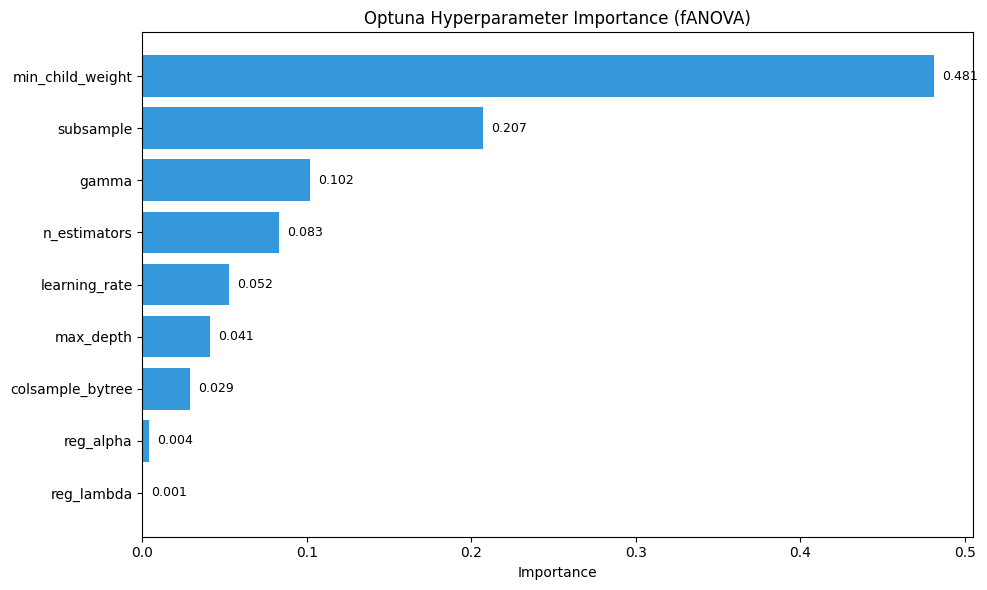

In [13]:
# Optuna hyperparameter importance
try:
    from optuna.importance import get_param_importances
    param_importances = get_param_importances(study)

    fig, ax = plt.subplots(figsize=(10, 6))
    params_sorted = dict(sorted(param_importances.items(), key=lambda x: x[1], reverse=True))
    bars = ax.barh(list(params_sorted.keys()), list(params_sorted.values()), color='#3498db')
    ax.set_xlabel('Importance')
    ax.set_title('Optuna Hyperparameter Importance (fANOVA)')
    ax.invert_yaxis()
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.005, bar.get_y() + bar.get_height()/2,
                f'{width:.3f}', ha='left', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'Could not compute hyperparameter importances: {e}')
    print('Falling back to optimization history plot...')
    fig, ax = plt.subplots(figsize=(10, 5))
    trials = [t.number for t in study.trials]
    values = [t.value for t in study.trials]
    ax.plot(trials, values, 'o-', alpha=0.7)
    ax.set_xlabel('Trial')
    ax.set_ylabel('Macro F1')
    ax.set_title('Optuna Optimization History')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

---
## Step 7B: SHAP Interpretability (Verification #3)

### What is SHAP?

**SHAP** (SHapley Additive exPlanations) is a game-theoretic approach to explain machine learning predictions. It assigns each feature an importance value for a particular prediction.

Unlike linear coefficients (which only work for linear models), SHAP values:
- Work for **any** model, including non-linear ones like XGBoost
- Show the **direction** of each feature's effect (positive/negative)
- Capture **interactions** between features
- Provide both **global** (model-level) and **local** (prediction-level) explanations

### What to look for

- **Summary plot (beeswarm)**: Shows all features ranked by importance. Each dot is a sample — colour indicates feature value (red = high, blue = low), position shows impact on prediction.
- **Dependence plots**: Show how a single feature's value relates to its SHAP value, revealing non-linear relationships.

=== SHAP Summary Plot ===


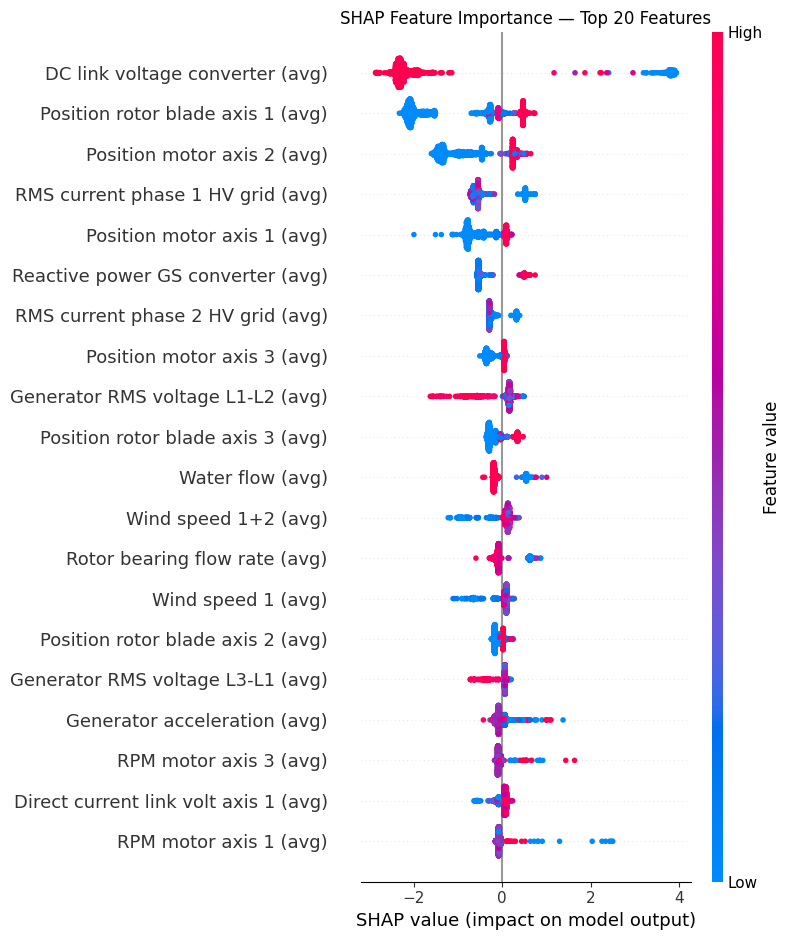

In [14]:
# SHAP analysis — using a sample for speed
shap_sample_size = min(2000, len(X_val))
X_shap = X_val.iloc[:shap_sample_size]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

# --- SHAP Summary Plot (Beeswarm) ---
print('=== SHAP Summary Plot ===')
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_shap, show=False, max_display=20)
plt.title('SHAP Feature Importance — Top 20 Features')
plt.tight_layout()
plt.show()

=== SHAP Dependence Plots ===


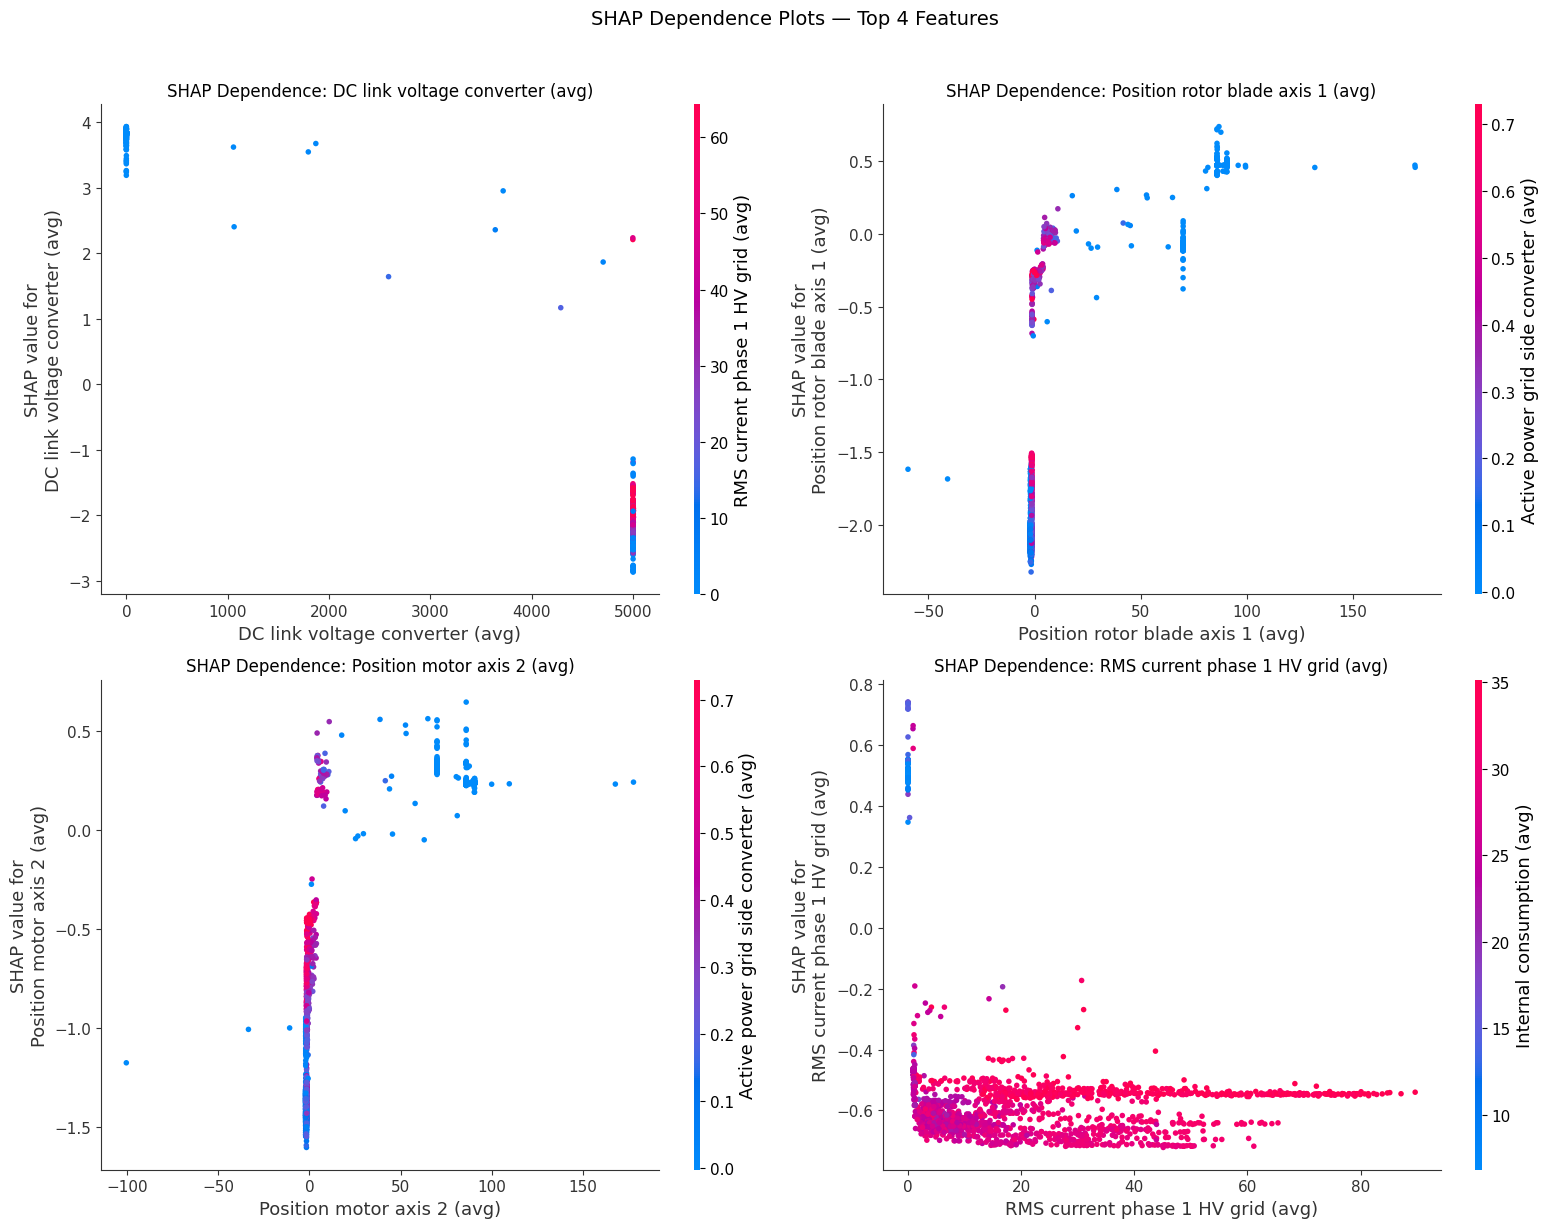

In [15]:
# --- SHAP Dependence Plots for Key Features ---
print('=== SHAP Dependence Plots ===')
# Find the top 4 features by mean absolute SHAP value
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_indices = np.argsort(mean_abs_shap)[-4:][::-1]
top_features = [feature_cols[i] for i in top_indices]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for idx, (feat, ax) in enumerate(zip(top_features, axes.flat)):
    shap.dependence_plot(feat, shap_values, X_shap, ax=ax, show=False)
    ax.set_title(f'SHAP Dependence: {feat}')
plt.suptitle('SHAP Dependence Plots — Top 4 Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Step 7C: Confusion Matrix (Verification #4)

### What to look for

The confusion matrix shows:
- **True Positives (TP)**: Correctly predicted Anomalous
- **True Negatives (TN)**: Correctly predicted Normal
- **False Positives (FP)**: Normal events incorrectly flagged as Anomalous
- **False Negatives (FN)**: Anomalies missed by the model

We plot both **raw counts** and the **Precision-Recall curve**, and compare against the baseline.

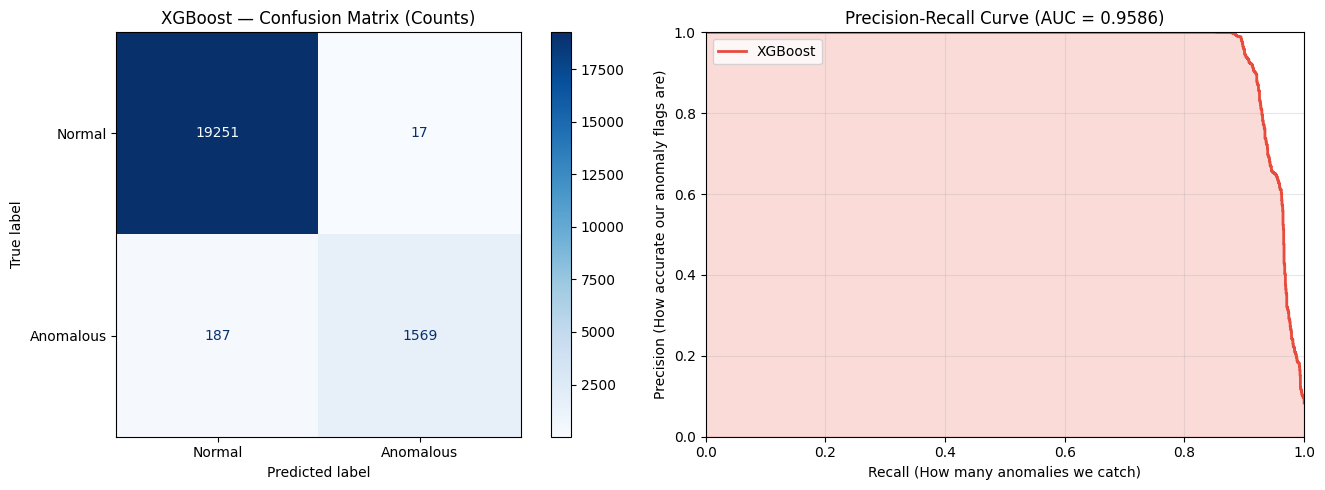

True Negatives  (correctly Normal):    19251
False Positives (Normal → Anomalous):  17
False Negatives (missed anomalies):    187
True Positives  (caught anomalies):    1569


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Confusion Matrix (Counts) ---
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Anomalous'])
disp.plot(ax=axes[0], cmap='Blues')
axes[0].set_title('XGBoost — Confusion Matrix (Counts)')

# --- Precision-Recall Curve ---
axes[1].plot(recall_vals, precision_vals, linewidth=2, color='#e74c3c', label='XGBoost')
axes[1].fill_between(recall_vals, precision_vals, alpha=0.2, color='#e74c3c')
axes[1].set_xlabel('Recall (How many anomalies we catch)')
axes[1].set_ylabel('Precision (How accurate our anomaly flags are)')
axes[1].set_title(f'Precision-Recall Curve (AUC = {pr_auc:.4f})')
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# Print detailed counts
tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (correctly Normal):    {tn}')
print(f'False Positives (Normal → Anomalous):  {fp}')
print(f'False Negatives (missed anomalies):    {fn}')
print(f'True Positives  (caught anomalies):    {tp}')

---
## Step 8: Predict Unknown Status

Now we apply the trained XGBoost model to all `"Unknown"` rows to predict whether they are Normal or Anomalous. No scaler is needed — XGBoost works directly on the raw features.

In [17]:
# Predict Unknown samples
unknown_preds = model.predict(X_unknown)
unknown_proba = model.predict_proba(X_unknown)[:, 1]

# Map back to labels
reverse_label_map = {0: 'Normal', 1: 'Anomalous'}
df_unknown = df_unknown.copy()
df_unknown['predicted_status'] = [reverse_label_map[p] for p in unknown_preds]
df_unknown['anomaly_probability'] = unknown_proba

print(f'=== Predictions for {len(df_unknown)} Unknown timestamps ===')
print(df_unknown['predicted_status'].value_counts())
print(f'\nAnomaly probability statistics:')
print(df_unknown['anomaly_probability'].describe())

=== Predictions for 12748 Unknown timestamps ===
predicted_status
Normal       11528
Anomalous     1220
Name: count, dtype: int64

Anomaly probability statistics:
count    12748.000000
mean         0.096019
std          0.291534
min          0.000106
25%          0.000115
50%          0.000154
75%          0.000772
max          0.999899
Name: anomaly_probability, dtype: float64


In [18]:
# --- Step 8: Predict Labels for Unknown Samples ---

# X_unknown and df_unknown were safely isolated in Step 3. Because feature engineering 
# was done in Step 2, these rows already contain their correct rolling/lag features 
# inherited from the continuous timeline.

print(f"Predicting status for {len(X_unknown)} 'Unknown' samples across both datasets...")

# 1. Generate predictions using the optimized XGBoost model
y_pred_unknown = model.predict(X_unknown)
y_proba_unknown = model.predict_proba(X_unknown)[:, 1]

# 2. Map encoded predictions (0, 1) back to the original text labels
inverse_label_map = {0: 'Normal', 1: 'Anomalous'}

# Use .values to prevent pandas index alignment issues (since df_unknown was sliced from df_combined)
df_unknown['predicted_status'] = pd.Series(y_pred_unknown).map(inverse_label_map).values
df_unknown['anomaly_probability'] = y_proba_unknown

# 3. Output overall prediction distributions
print("\n=== Prediction Distribution for 'Unknown' Timestamps ===")
print(df_unknown['predicted_status'].value_counts(dropna=False))

# 4. View a chronological sample of the predicted Unknowns to verify
df_unknown_sorted = df_unknown.sort_values(['asset_id', 'time_stamp'])
print("\n=== Sample Predictions ===")
print(df_unknown_sorted[['time_stamp', 'asset_id', 'predicted_status', 'anomaly_probability']].head(15))

Predicting status for 12748 'Unknown' samples across both datasets...

=== Prediction Distribution for 'Unknown' Timestamps ===
predicted_status
Normal       11528
Anomalous     1220
Name: count, dtype: int64

=== Sample Predictions ===
               time_stamp  asset_id predicted_status  anomaly_probability
52560 2023-12-01 22:50:00        38           Normal             0.000116
52561 2023-12-01 23:00:00        38           Normal             0.000125
52562 2023-12-01 23:10:00        38           Normal             0.000122
52563 2023-12-01 23:20:00        38           Normal             0.000128
52564 2023-12-01 23:30:00        38           Normal             0.000123
52565 2023-12-01 23:40:00        38           Normal             0.000119
52566 2023-12-01 23:50:00        38           Normal             0.000129
52567 2023-12-02 00:00:00        38           Normal             0.000116
52568 2023-12-02 00:10:00        38           Normal             0.000116
52569 2023-12-02 00:20:

---
## Step 8A: Law of Large Numbers — Do Unknown Predictions Converge? (Verification #5)

### What is the Law of Large Numbers (LLN)?

The LLN states that as the number of independent samples grows, the sample mean converges to the expected (population) mean. Here we apply this idea:

- We compute the **cumulative anomaly rate** for Unknown samples sorted chronologically.
- If predictions are statistically stable, this running proportion should **converge** to a fixed value.
- We compare against the **training set anomaly rate** (baseline).

### What to look for

- **Convergence**: If the curve flattens, the model is consistent — Unknown data behaves similarly to training data.
- **Divergence**: If the curve drifts/oscillates, it suggests distributional shift.

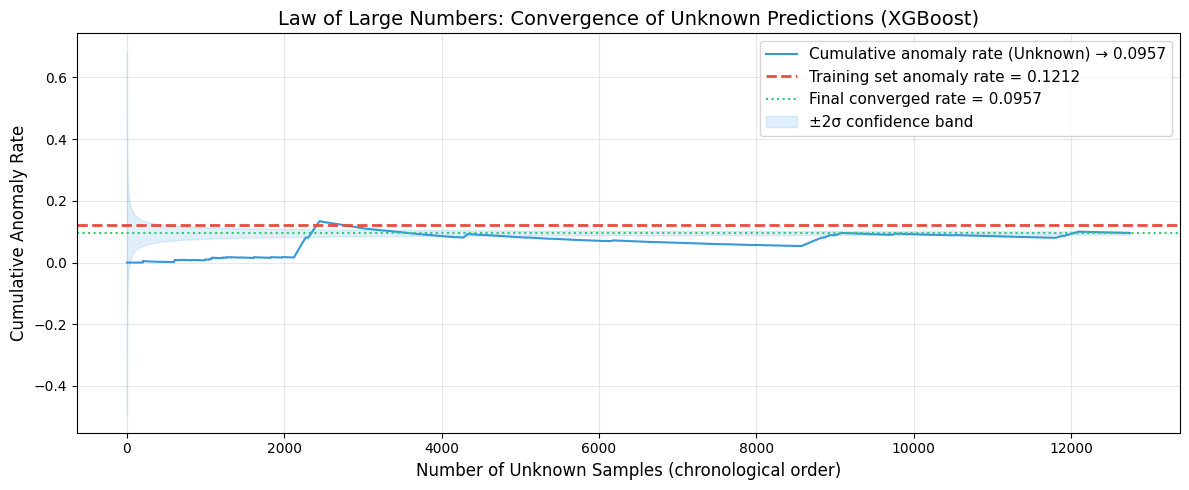


=== Law of Large Numbers Summary (XGBoost) ===
Training anomaly rate:          0.1212 (12.12%)
Unknown converged anomaly rate: 0.0957 (9.57%)
Difference:                     0.0255
→ The Unknown predictions converge close to the training distribution — the XGBoost model treats Unknown data consistently.


In [19]:
f_unknown_sorted = df_unknown.sort_values('time_stamp').reset_index(drop=True)

# 2. Compute cumulative anomaly rate using Pandas expanding window
# (Make sure 'predicted_status' matches the exact string output of your model)
predicted_labels = (df_unknown_sorted['predicted_status'] == 'Anomalous').astype(int)
cumulative_anomaly_rate = predicted_labels.expanding().mean()
sample_indices = np.arange(1, len(cumulative_anomaly_rate) + 1)

# 3. Get baselines and final rates
train_anomaly_rate = y_train.mean()
final_rate = cumulative_anomaly_rate.iloc[-1]

# 4. Plotting
fig, ax = plt.subplots(figsize=(12, 5))

# Plot the main convergence line
ax.plot(sample_indices, cumulative_anomaly_rate, color='#3498db', linewidth=1.5,
        label=f'Cumulative anomaly rate (Unknown) → {final_rate:.4f}')

# Plot the Training Baseline
ax.axhline(y=train_anomaly_rate, color='#e74c3c', linestyle='--', linewidth=2,
           label=f'Training set anomaly rate = {train_anomaly_rate:.4f}')

# Plot the Final Converged Rate
ax.axhline(y=final_rate, color='#2ecc71', linestyle=':', linewidth=1.5,
           label=f'Final converged rate = {final_rate:.4f}')

# Formating the graph
ax.set_xlabel('Number of Unknown Samples (chronological order)', fontsize=12)
ax.set_ylabel('Cumulative Anomaly Rate', fontsize=12)
ax.set_title('Law of Large Numbers: Convergence of Unknown Predictions (XGBoost)', fontsize=14)
ax.grid(True, alpha=0.3)

# 5. Add a shaded confidence band (± 2 std of Bernoulli proportion)
p = final_rate
margin = 2 * np.sqrt(p * (1 - p) / sample_indices)
ax.fill_between(sample_indices, final_rate - margin, final_rate + margin,
                alpha=0.15, color='#3498db', label='±2σ confidence band')

# Add legend (call once at the end so it grabs all labels)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

# 6. Printed Insight Summary
print(f'\n=== Law of Large Numbers Summary (XGBoost) ===')
print(f'Training anomaly rate:          {train_anomaly_rate:.4f} ({train_anomaly_rate*100:.2f}%)')
print(f'Unknown converged anomaly rate: {final_rate:.4f} ({final_rate*100:.2f}%)')
print(f'Difference:                     {abs(final_rate - train_anomaly_rate):.4f}')

if abs(final_rate - train_anomaly_rate) < 0.05:
    print('→ The Unknown predictions converge close to the training distribution — the XGBoost model treats Unknown data consistently.')
else:
    print('→ There is a notable gap between the Unknown and training anomaly rates — potential distributional shift.')

---
## Step 8B: Scatter Plot — Wind Speed vs Active Power (Verification #6)

### What is this?

This scatter plot compares **Wind Speed** (`Wind speed 1+2 (avg)`) against **Active Power** (`Active power grid side converter (avg)`) on the validation set, coloured by the model's predicted label.

### What to look for

- The power curve shape should be visible (S-curve or similar).
- Anomalous predictions (red) should cluster in physically unusual regions — e.g., high wind but low power, or power at zero wind.
- If anomalies scatter randomly everywhere, the model may not be capturing the right physics.

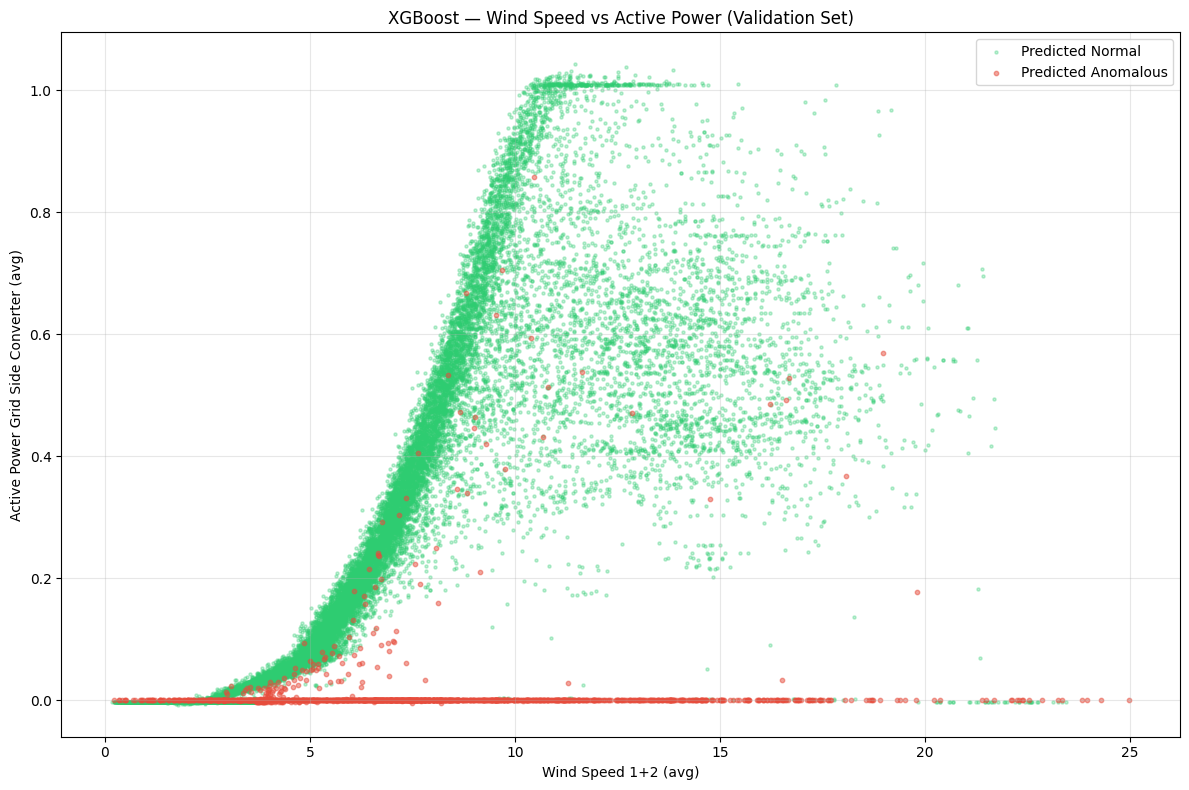

In [20]:
fig, ax = plt.subplots(figsize=(12, 8))

# Validation predictions
val_df = X_val.copy()
val_df['predicted'] = y_pred

normal_mask = val_df['predicted'] == 0
anomalous_mask = val_df['predicted'] == 1

wind_col = 'Wind speed 1+2 (avg)'
power_col = 'Active power grid side converter (avg)'

ax.scatter(val_df.loc[normal_mask, wind_col],
           val_df.loc[normal_mask, power_col],
           c='#2ecc71', alpha=0.3, s=5, label='Predicted Normal')
ax.scatter(val_df.loc[anomalous_mask, wind_col],
           val_df.loc[anomalous_mask, power_col],
           c='#e74c3c', alpha=0.5, s=10, label='Predicted Anomalous')

ax.set_xlabel('Wind Speed 1+2 (avg)')
ax.set_ylabel('Active Power Grid Side Converter (avg)')
ax.set_title('XGBoost — Wind Speed vs Active Power (Validation Set)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 8C: Signal Overlay Plot (Verification #7)

### What is this?

A timeline plot overlaying the model's prediction errors onto a key feature (Wind Speed). This visualises *where in time and signal space* the model fails:

- **Red dots** = False Positives (Normal events flagged as Anomalous)
- **Purple dots** = False Negatives (Anomalies missed by the model)

### What to look for

- Do errors cluster at specific times or signal values?
- Are FPs happening during high-variability periods?
- Are FNs concentrated in specific wind regimes?

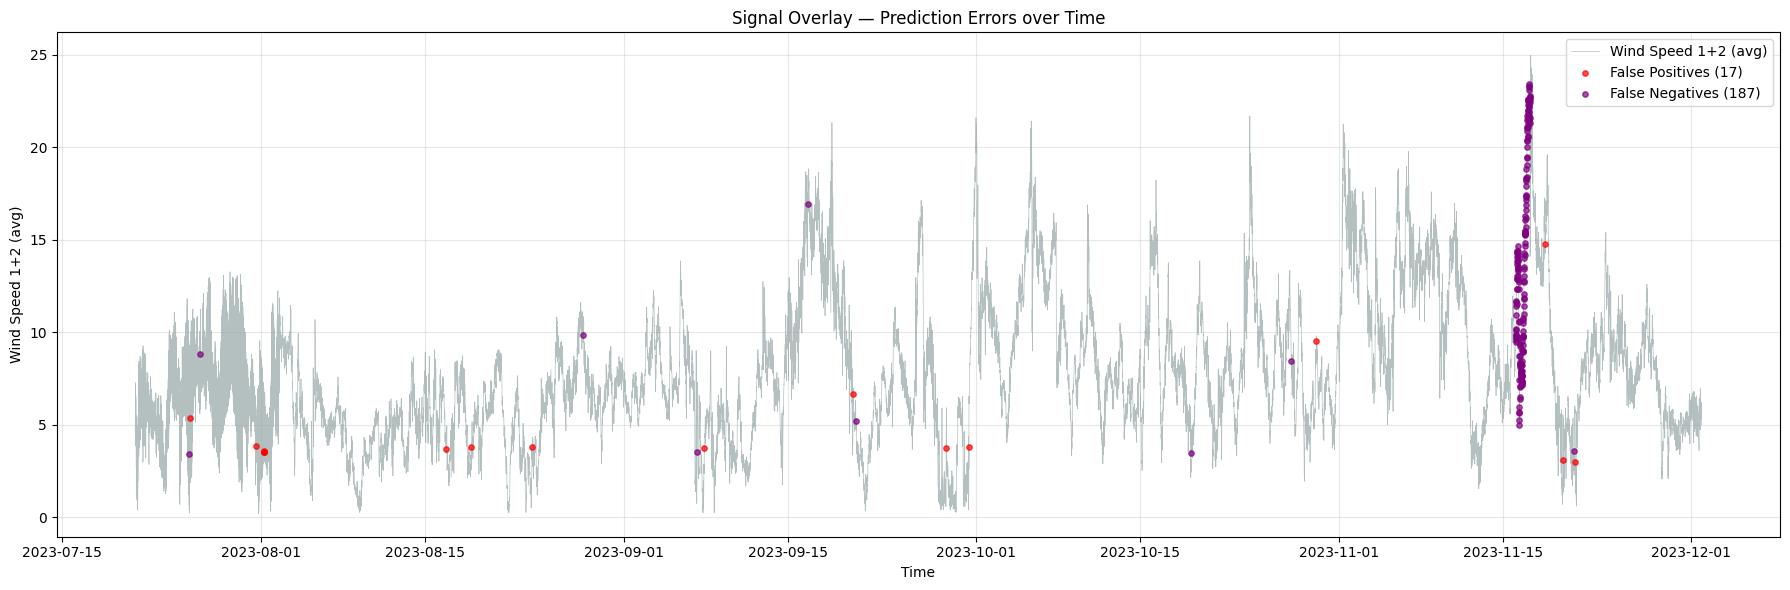

False Positives: 17
False Negatives: 187


In [21]:
# Signal Overlay Plot
val_timeline = df_labeled_sorted.iloc[split_idx:].copy()
val_timeline['y_true'] = y_val.values
val_timeline['y_pred'] = y_pred

false_pos_mask = (val_timeline['y_true'] == 0) & (val_timeline['y_pred'] == 1)
false_neg_mask = (val_timeline['y_true'] == 1) & (val_timeline['y_pred'] == 0)

fig, ax = plt.subplots(figsize=(18, 6))

# Plot wind speed as continuous line
ax.plot(val_timeline['time_stamp'], val_timeline['Wind speed 1+2 (avg)'],
        linewidth=0.5, color='#95a5a6', alpha=0.7, label='Wind Speed 1+2 (avg)')

# Overlay errors
ax.scatter(val_timeline.loc[false_pos_mask, 'time_stamp'],
           val_timeline.loc[false_pos_mask, 'Wind speed 1+2 (avg)'],
           c='red', s=15, alpha=0.7, zorder=5, label=f'False Positives ({false_pos_mask.sum()})')
ax.scatter(val_timeline.loc[false_neg_mask, 'time_stamp'],
           val_timeline.loc[false_neg_mask, 'Wind speed 1+2 (avg)'],
           c='purple', s=15, alpha=0.7, zorder=5, label=f'False Negatives ({false_neg_mask.sum()})')

ax.set_xlabel('Time')
ax.set_ylabel('Wind Speed 1+2 (avg)')
ax.set_title('Signal Overlay — Prediction Errors over Time')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'False Positives: {false_pos_mask.sum()}')
print(f'False Negatives: {false_neg_mask.sum()}')

---
## Step 8D: Hourly Error Analysis (Verification #8)

### What is this?

We group prediction errors by **hour of the day** to find systematic temporal patterns. Wind turbine behaviour changes throughout the day (temperature, wind patterns), and so might model errors.

### What to look for

- Are errors concentrated at certain hours? If so, the model may struggle with specific operating conditions.
- A flat distribution suggests errors are random with respect to time of day — generally a good sign.

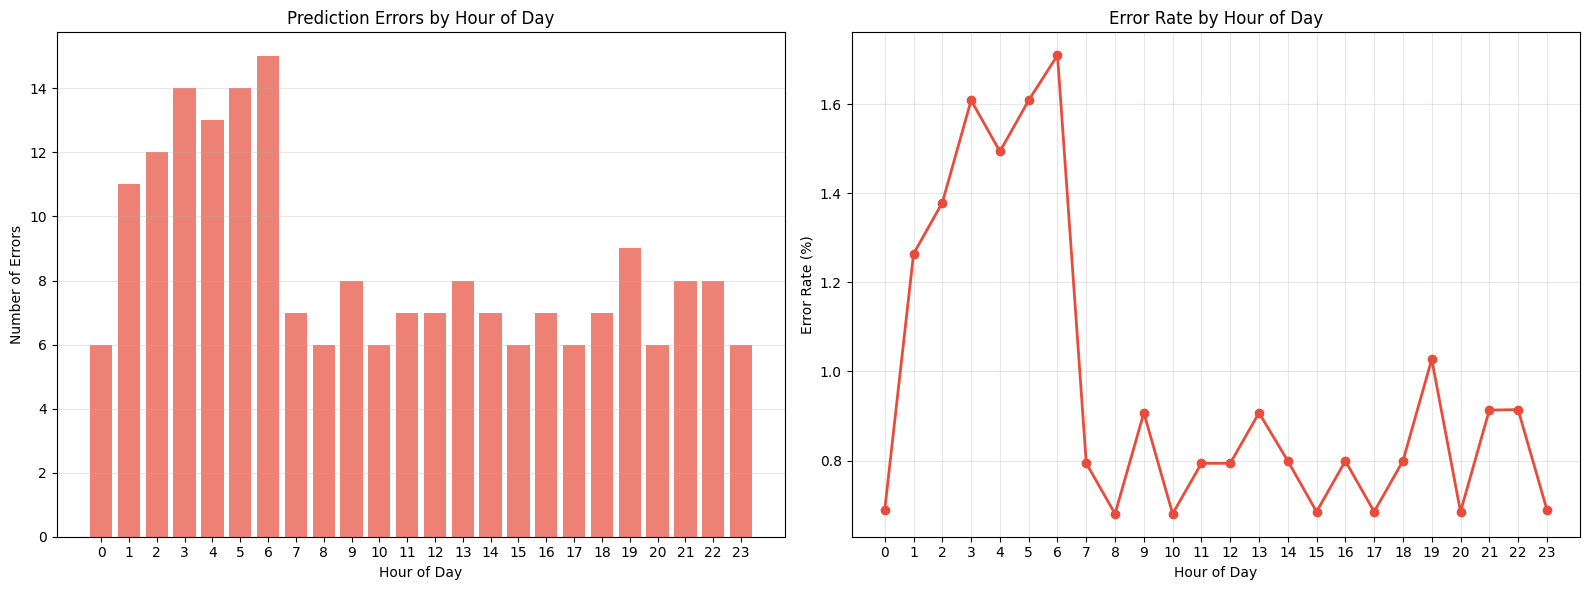

Highest error rate: hour 6 (1.7%)
Lowest error rate:  hour 8 (0.7%)


In [22]:
# Hourly Error Analysis
val_timeline['error'] = (val_timeline['y_true'] != val_timeline['y_pred']).astype(int)
val_timeline['hour_of_day'] = val_timeline['time_stamp'].dt.hour

hourly_errors = val_timeline.groupby('hour_of_day').agg(
    total=('error', 'count'),
    errors=('error', 'sum')
).reset_index()
hourly_errors['error_rate'] = hourly_errors['errors'] / hourly_errors['total']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart: error count by hour
axes[0].bar(hourly_errors['hour_of_day'], hourly_errors['errors'], color='#e74c3c', alpha=0.7)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Number of Errors')
axes[0].set_title('Prediction Errors by Hour of Day')
axes[0].set_xticks(range(24))
axes[0].grid(True, alpha=0.3, axis='y')

# Line chart: error rate by hour
axes[1].plot(hourly_errors['hour_of_day'], hourly_errors['error_rate'] * 100,
             'o-', color='#e74c3c', linewidth=2, markersize=6)
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Error Rate (%)')
axes[1].set_title('Error Rate by Hour of Day')
axes[1].set_xticks(range(24))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
peak_hour = hourly_errors.loc[hourly_errors['error_rate'].idxmax()]
low_hour = hourly_errors.loc[hourly_errors['error_rate'].idxmin()]
print(f'Highest error rate: hour {int(peak_hour["hour_of_day"])} ({peak_hour["error_rate"]*100:.1f}%)')
print(f'Lowest error rate:  hour {int(low_hour["hour_of_day"])} ({low_hour["error_rate"]*100:.1f}%)')

---
## Summary — XGBoost vs Baseline Comparison

This notebook implemented an advanced **XGBoost** model for wind turbine anomaly detection with the following enhancements over the Logistic Regression baseline:

| Aspect | Baseline | XGBoost |
|---|---|---|
| Features | Temporal only | Temporal + Lag + Rolling stats |
| Class balancing | `class_weight='balanced'` | `scale_pos_weight` |
| Tuning | None | **Optuna** (50 trials, TimeSeriesSplit) |
| Scaling | StandardScaler | Not required |
| Interpretability | Linear coefficients | **SHAP** values |

### Verification Checklist

1. ✅ **Standard Metrics** — Macro F1 and PR-AUC computed and compared to baseline
2. ✅ **Optuna Analysis** — Hyperparameter importance plotted
3. ✅ **SHAP Interpretability** — Summary and dependence plots generated
4. ✅ **Confusion Matrix** — Counts and PR curve plotted
5. ✅ **LLN Analysis** — Convergence of Unknown predictions checked
6. ✅ **Scatter Plot** — Wind Speed vs Active Power coloured by prediction
7. ✅ **Signal Overlay** — FP/FN errors overlaid on Wind Speed timeline
8. ✅ **Hourly Error Analysis** — Error patterns by hour of day examined

---
## Step 10: Instruction #3 - Visualizing Predictions & Explaining Anomalies

To understand what causes 'Anomalous' behavior according to our model, we can look at the wind turbine **Power Curve** (Wind Speed vs Active Power) to see if the anomalous points fall into expected failure zones (like underperformance or over-speed).


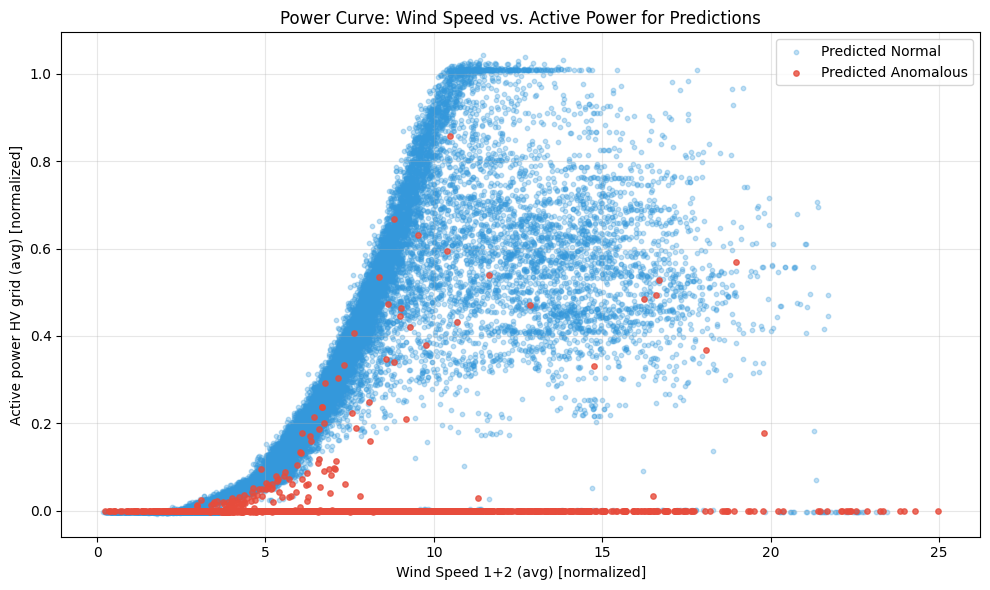

In [31]:
# 1. Power Curve (Wind Speed vs Active Power)
fig, ax = plt.subplots(figsize=(10, 6))

# Let's use val_timeline which we already created in the previous cell.
normal_pts = val_timeline[val_timeline['y_pred'] == 0]
anom_pts = val_timeline[val_timeline['y_pred'] == 1]

ax.scatter(normal_pts['Wind speed 1+2 (avg)'], normal_pts['Active power HV grid (avg)'], 
           c='#3498db', alpha=0.3, s=10, label='Predicted Normal')
ax.scatter(anom_pts['Wind speed 1+2 (avg)'], anom_pts['Active power HV grid (avg)'], 
           c='#e74c3c', alpha=0.8, s=15, label='Predicted Anomalous', zorder=5)

ax.set_title('Power Curve: Wind Speed vs. Active Power for Predictions')
ax.set_xlabel('Wind Speed 1+2 (avg) [normalized]')
ax.set_ylabel('Active power HV grid (avg) [normalized]')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## Step 11: Instruction #4 - Identifying Model Limitations

Using visualizations, we can identify regimes where the model struggles (high False Positives or False Negatives). For instance, does the model fail more during specific hours of the day?


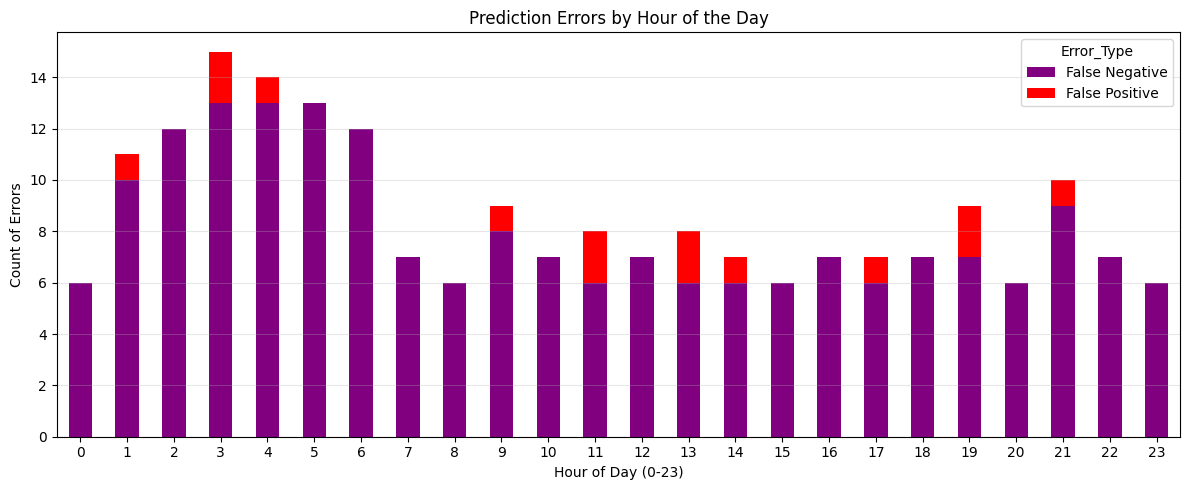

In [32]:
# Analyze Errors
val_timeline['time_stamp_dt'] = pd.to_datetime(val_timeline['time_stamp'])
val_timeline['Error_Type'] = 'Correct'
val_timeline.loc[(val_timeline['y_true'] == 0) & (val_timeline['y_pred'] == 1), 'Error_Type'] = 'False Positive'
val_timeline.loc[(val_timeline['y_true'] == 1) & (val_timeline['y_pred'] == 0), 'Error_Type'] = 'False Negative'

errors_df = val_timeline[val_timeline['Error_Type'] != 'Correct'].copy()
errors_df['hour'] = errors_df['time_stamp_dt'].dt.hour

# Plot Errors by Hour of Day
fig, ax = plt.subplots(figsize=(12, 5))
error_counts = errors_df.groupby(['hour', 'Error_Type']).size().unstack(fill_value=0)

# Ensure all hours 0-23 are present
for h in range(24):
    if h not in error_counts.index:
        error_counts.loc[h] = 0
error_counts = error_counts.sort_index()

colors = []
color_dict = {'False Positive': 'red', 'False Negative': 'purple'}
for col in error_counts.columns:
    colors.append(color_dict.get(col, 'black'))

if not error_counts.empty:
    error_counts.plot(kind='bar', stacked=True, ax=ax, color=colors)
ax.set_title('Prediction Errors by Hour of the Day')
ax.set_xlabel('Hour of Day (0-23)')
ax.set_ylabel('Count of Errors')
plt.xticks(rotation=0)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


---
## Step 12: Instruction #5 - Production Deployment Failure Risks

Here are 3 concrete reasons why deploying this model in production might fail:

1. **Concept Drift / Environmental Changes:** Over time, component wear-and-tear and seasonal weather variations (such as blade icing or extreme heat variations) alter the true baseline of 'normal' behavior. The model, trained on fixed historical data, may mistakenly flag normal aging as anomalous, leading to high false-positive rates and alert fatigue.
2. **Sensor Degradation or Failure:** In production, physical sensors degrade or disconnect. If critical input features (like wind speed or temperature) start feeding corrupted values or NaNs into the XGBoost model, the outputs will be meaningless, potentially crashing downstream automation or triggering false shut-downs.
3. **Data Latency and Pipeline Reliability:** Our offline training assumes data is perfectly synchronized, cleaned, and available every 10 minutes. In real-world telemetry arrays, network dropouts and asynchronous message queues mean features might arrive late or out of order. If the inference microservice isn't resilient to missing timely data, it will fail to predict anomalies accurately in real-time.


---
## Step 13: Instruction #6 - Additional Data Sources

In an ideal setting, to provide more predictive value and actionable insights, the following additional data sources should be added:

1. **Vibration and Acoustic Data (CMS):** Condition Monitoring Systems placed directly on the drivetrain (gearbox, main bearing, generator). High-frequency vibration data is the industry standard for predictive maintenance because it detects mechanical fatigue (like micro-cracks in gear teeth) weeks or months before macro sensors (like temperature or power output) show any signs of deviating.
2. **SCADA Error and Maintenance Logs (Categorical Labels):** Currently, 'anomalous' is a broad, manually annotated binary tag. By integrating OEM error codes and the maintenance work-order system, we could re-frame this as a **multi-class classification problem** to predict the *specific component* failing (e.g., 'Pitch Motor Fault' vs 'Yaw Misalignment'). Furthermore, it filters out periods where the turbine was offline for scheduled maintenance (which isn't an anomaly, but human intervention).
3. **High-Resolution Meteorological Masts / Upwind Lidar:** Wind speed measured at the nacelle anemometer is often disturbed by the rotor itself. Upwind LIDAR or Met-mast data gives accurate incoming wind profiles (shear, turbulence intensity, specific air density). This improves the theoretical power curve accuracy, helping distinguish true aerodynamic underperformance from internal mechanical faults.
